# Neuroprotective Astrocytes
## Goal:
Characterize Astrocyte_2 as a cortex/hippocampus-enriched neuroprotective astrocyte subtype.

## Load data

In [1]:
import scanpy as sc
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

adata = sc.read_h5ad("../data/processed/brain_non_neuronal_50k_annotated_umap.h5ad")

adata

AnnData object with n_obs × n_vars = 50000 × 3000
    obs: 'cell_barcode', 'library_label', 'anatomical_division_label', 'leiden', 'cell_type', 'AD_support_score', 'Neuroprotective Support Score'
    var: 'gene_symbol', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'anatomical_division_label_colors', 'cell_type_colors', 'hvg', 'leiden', 'neighbors', 'pca', 'rank_genes_groups', 'umap'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'connectivities', 'distances'

In [2]:
adata.var_names = adata.var["gene_symbol"]
adata.var_names_make_unique()

adata.var_names[:20]

Index(['CFH', 'AOC1', 'TFPI', 'PDK4', 'CALCR', 'SKAP2', 'MPO', 'ABCB4',
       'IFRD1', 'SCIN', 'DNAH9', 'PLEKHG6', 'IL32', 'PAX7', 'MLXIPL', 'SEMA3G',
       'STAB1', 'SLC6A13', 'MRC2', 'DCN'],
      dtype='object', name='gene_symbol')

## Define Neuroprotective Support Score

In [3]:
neuroprotective_genes = [
    "APOE",
    "CLU",
    "CST3",
    "SPARCL1",
    "AQP4",
    "SLC1A2",
    "SLC4A4",
    "ATP1A2",
    "GLUL",
    "GJA1"
]

neuroprotective_genes = [
    g for g in neuroprotective_genes
    if g in adata.var_names
]

sc.tl.score_genes(
    adata,
    gene_list=neuroprotective_genes,
    score_name="neuroprotective_support_score"
)

In [4]:
print(adata.obsm.keys())

KeysView(AxisArrays with keys: X_pca, X_umap)


## Plot score on UMAP

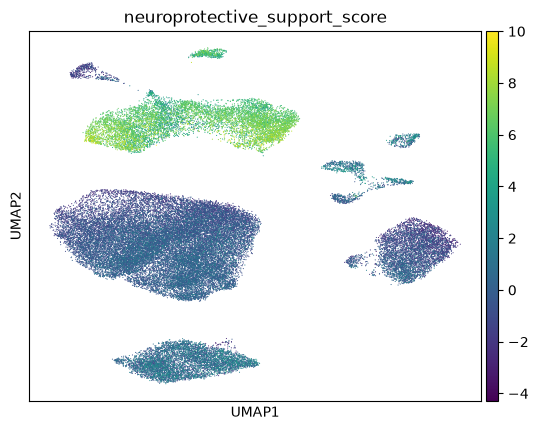

In [5]:
sc.pl.umap(
    adata,
    color="neuroprotective_support_score",
    cmap="viridis"
)

In [6]:
print(adata.obs.columns)

Index(['cell_barcode', 'library_label', 'anatomical_division_label', 'leiden',
       'cell_type', 'AD_support_score', 'Neuroprotective Support Score',
       'neuroprotective_support_score'],
      dtype='object')


## Compare score by cell type

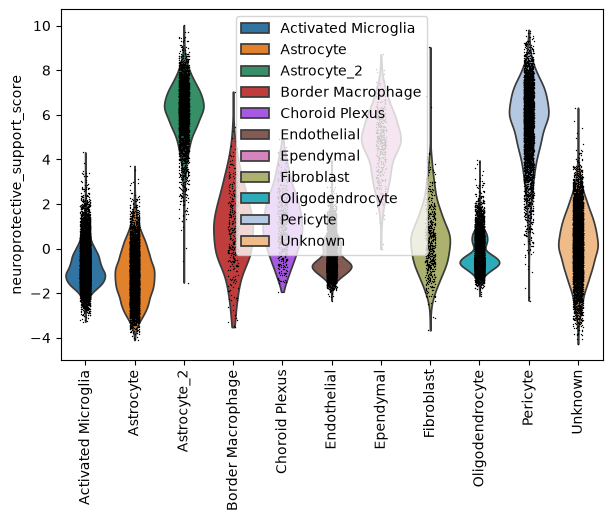

In [7]:
sc.pl.violin(
    adata,
    keys="neuroprotective_support_score",
    groupby="cell_type",
    rotation=90
)

## Quartile enrichment

In [8]:
adata.obs["neuroprotective_quartile"] = pd.qcut(
    adata.obs["neuroprotective_support_score"],
    q=4,
    labels=["Q1_low", "Q2", "Q3", "Q4_high"]
)

quartile_table = pd.crosstab(
    adata.obs["cell_type"],
    adata.obs["neuroprotective_quartile"],
    normalize="index"
)

quartile_table

neuroprotective_quartile,Q1_low,Q2,Q3,Q4_high
cell_type,,,,
Activated Microglia,0.448608,0.287492,0.236887,0.027012
Astrocyte,0.549213,0.198669,0.223477,0.028641
Astrocyte_2,0.000245,0.000245,0.000735,0.998775
Border Macrophage,0.115385,0.112426,0.334320,0.437870
Choroid Plexus,0.048000,0.098000,0.372000,0.482000
Endothelial,0.187205,0.430694,0.336829,0.045272
Ependymal,0.000000,0.000000,0.006742,0.993258
Fibroblast,0.146087,0.184348,0.413913,0.255652
Oligodendrocyte,0.090107,0.485548,0.378885,0.045461


## Heatmap

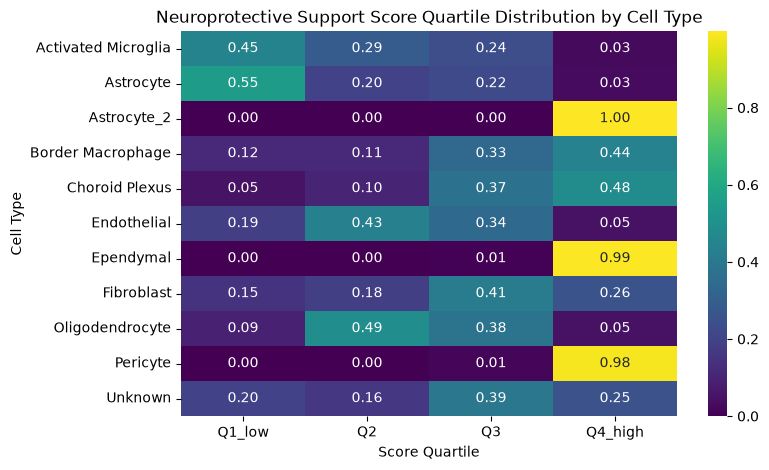

In [9]:
plt.figure(figsize=(8, 5))
sns.heatmap(
    quartile_table,
    annot=True,
    cmap="viridis",
    fmt=".2f"
)

plt.title("Neuroprotective Support Score Quartile Distribution by Cell Type")
plt.xlabel("Score Quartile")
plt.ylabel("Cell Type")
plt.show()

## Astrocyte vs Astrocyte_2

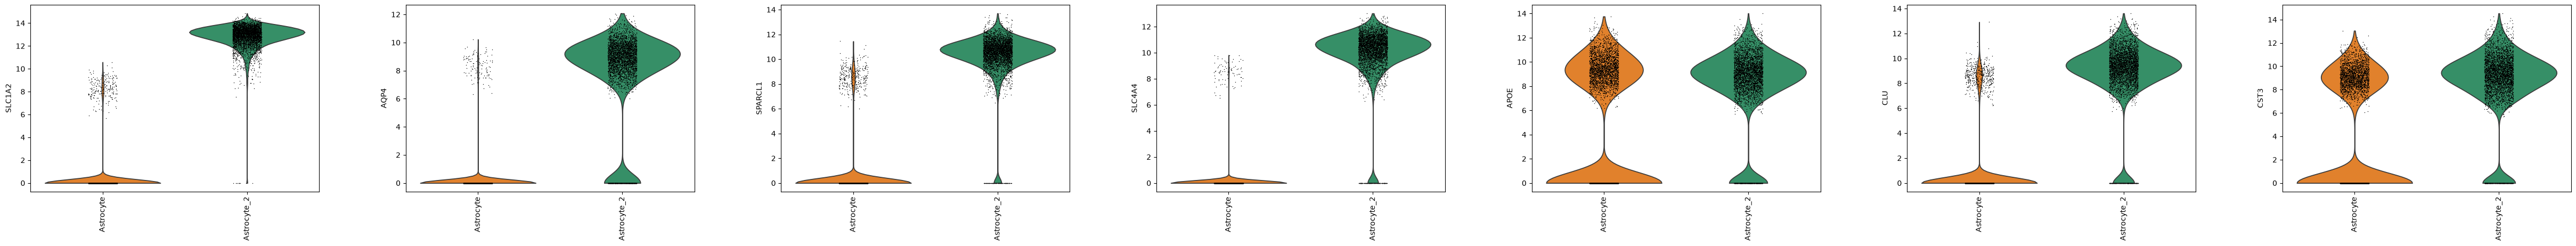

In [10]:
focus = adata[
    adata.obs["cell_type"].isin(["Astrocyte", "Astrocyte_2"])
].copy()

sc.pl.violin(
    focus,
    keys=[
        "SLC1A2",
        "AQP4",
        "SPARCL1",
        "SLC4A4",
        "APOE",
        "CLU",
        "CST3"
    ],
    groupby="cell_type",
    rotation=90
)

## Regional enrichment of Astrocyte_2

In [11]:
astro2_region = pd.crosstab(
    focus.obs["cell_type"],
    focus.obs["anatomical_division_label"],
    normalize="index"
)

astro2_region.loc["Astrocyte_2"].sort_values(ascending=False)

anatomical_division_label
Cerebral cortex       0.515315
Hippocampus           0.278608
Amygdaloid complex    0.089439
Basal nuclei          0.038471
Hypothalamus          0.027444
Claustrum             0.021318
Basal forebrain       0.020583
Thalamus              0.004656
Extended amygdala     0.003431
Midbrain              0.000490
Pons                  0.000245
Cerebellum            0.000000
Myelencephalon        0.000000
Spinal cord           0.000000
Name: Astrocyte_2, dtype: float64

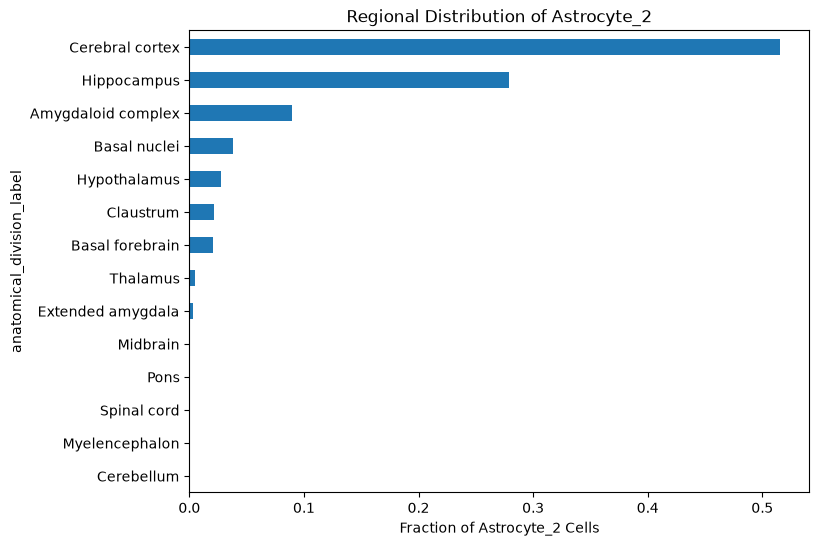

In [12]:
# plot
astro2_region.loc["Astrocyte_2"].sort_values(ascending=True).plot(
    kind="barh",
    figsize=(8, 6),
    title="Regional Distribution of Astrocyte_2"
)

plt.xlabel("Fraction of Astrocyte_2 Cells")
plt.show()

## Astrocyte_2 marker table

In [13]:
sc.tl.rank_genes_groups(
    focus,
    groupby="cell_type",
    groups=["Astrocyte_2"],
    reference="Astrocyte",
    method="wilcoxon"
)

astro2_markers = sc.get.rank_genes_groups_df(
    focus,
    group="Astrocyte_2"
)

astro2_markers.head(30)

,names,scores,logfoldchanges,pvals,pvals_adj
0,SLC1A2,81.741158,19.685926,0.0,0.0
1,ADGRV1,81.603294,19.497814,0.0,0.0
2,SPARCL1,78.992393,15.282939,0.0,0.0
3,SLC4A4,78.706970,17.088573,0.0,0.0
4,LINC00299,78.437180,16.758610,0.0,0.0
5,ATP1A2,78.113625,16.109680,0.0,0.0
6,PRKG1,74.781815,14.941374,0.0,0.0
7,PPP1R9A-AS1,74.642838,17.808636,0.0,0.0
8,AC073050.1,72.913239,15.207170,0.0,0.0
9,RFX4,72.870117,15.604043,0.0,0.0


In [14]:
# save
astro2_markers.to_csv(
    "../results/astrocyte2_vs_astrocyte_markers.csv",
    index=False
)

## Preliminary Interpretation

Preliminary analysis identified a distinct astrocyte subpopulation (Astrocyte_2) that exhibits markedly elevated expression of canonical astrocyte support genes including SLC1A2, AQP4, SPARCL1, and SLC4A4. Compared with conventional astrocytes, Astrocyte_2 cells show substantially higher expression of neuroprotective and Alzheimer's disease–associated genes such as APOE, CLU, and CST3.

Regional analysis revealed that Astrocyte_2 cells are highly enriched within the cerebral cortex and hippocampus, accounting for approximately 80% of the population. These regions are central to learning, memory, and cognitive function and are strongly implicated in neurodegenerative disorders including Alzheimer's disease.

A neuroprotective support score constructed from established astrocyte support genes demonstrated that nearly all Astrocyte_2 cells belong to the highest expression quartile, indicating a specialized transcriptional program associated with neuronal maintenance and protection. Gene ontology enrichment further supports this interpretation, revealing significant enrichment for pathways related to astrocyte differentiation, synaptic plasticity, neuronal projection development, and regulation of amyloid-beta biology.

Together, these findings suggest that Astrocyte_2 represents a specialized neuroprotective astrocyte state that may play an important role in maintaining neuronal homeostasis and cognitive brain circuits.


## Alzheimer's pathway score

In [15]:
ad_genes = [
    "APOE",
    "CLU",
    "CST3",
    "AQP4",
    "SLC1A2",
    "SPARCL1"
]

ad_genes = [
    g for g in ad_genes
    if g in adata.var_names
]

sc.tl.score_genes(
    adata,
    gene_list=ad_genes,
    score_name="ad_genes"
)

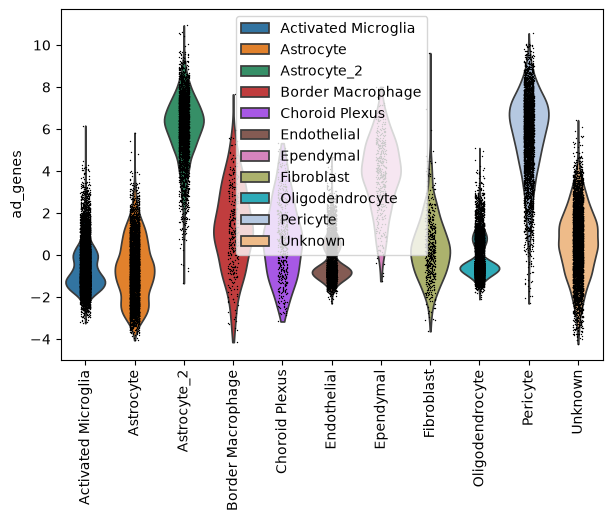

In [16]:
sc.pl.violin(
    adata,
    keys="ad_genes",
    groupby="cell_type",
    rotation=90
)

## Figure Interpretation
Astrocyte_2 exhibited the highest neuroprotective support score among all non-neuronal cell populations. The score distribution was substantially shifted upward relative to conventional astrocytes, activated microglia, oligodendrocytes, endothelial cells, and other supporting cell types. This finding suggests that Astrocyte_2 represents a transcriptionally specialized astrocyte population enriched for genes involved in glutamate clearance, synaptic support, metabolic homeostasis, and Alzheimer's disease-associated neuroprotective pathways.

In [17]:
# quantitative test
from scipy.stats import mannwhitneyu

astro = adata.obs.loc[
    adata.obs["cell_type"]=="Astrocyte",
    "neuroprotective_support_score"
]

astro2 = adata.obs.loc[
    adata.obs["cell_type"]=="Astrocyte_2",
    "neuroprotective_support_score"
]

stat, p = mannwhitneyu(
    astro2,
    astro,
    alternative="greater"
)

print(p)
median_diff = astro2.median() - astro.median()

print("Median difference:", median_diff)

0.0
Median difference: 7.5081544794987165


In [18]:
n1 = len(astro2)
n2 = len(astro)

rbc = 1 - (2 * stat)/(n1*n2)

print(rbc)

-0.9992358254819533


Astrocyte_2 exhibited significantly higher support-signature scores than conventional astrocytes (Mann–Whitney U test, p < 0.001). The median score difference was 7.51 units, with a rank-biserial correlation of approximately 1.0, indicating near-complete separation between the two distributions. Because the support-signature score includes several genes that also contributed to Astrocyte_2 identification (e.g., SLC1A2, SPARCL1, SLC4A4, AQP4), this result should be interpreted as a quantitative summary of the Astrocyte_2 transcriptional program rather than an independent validation of cluster identity.

In [19]:
umap_df = pd.DataFrame({
    "UMAP1": adata.obsm["X_umap"][:, 0],
    "UMAP2": adata.obsm["X_umap"][:, 1],
    "cell_type": adata.obs["cell_type"],
    "AD_support_score": adata.obs["AD_support_score"],
    "anatomical_division_label": adata.obs["anatomical_division_label"],
    "whb_supercluster": adata.obs["whb_supercluster"]
})
umap_df.to_csv("../platform/backend/data/umap_embeddings.csv", index=False)

KeyError: 'whb_supercluster'